In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.shape

(9994, 21)

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
# Make a copy
sales_df = df.copy()

# Convert date columns
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])
sales_df["Ship Date"] = pd.to_datetime(sales_df["Ship Date"])

# Create new date features
sales_df["Order Year"] = sales_df["Order Date"].dt.year
sales_df["Order Month"] = sales_df["Order Date"].dt.month
sales_df["Order Month Name"] = sales_df["Order Date"].dt.month_name()
sales_df["Order Quarter"] = sales_df["Order Date"].dt.quarter
sales_df["Year-Month"] = sales_df["Order Date"].dt.to_period("M").astype(str)

# Shipping delay
sales_df["Shipping Days"] = (sales_df["Ship Date"] - sales_df["Order Date"]).dt.days

# Revenue metrics
sales_df["Profit Margin"] = sales_df["Profit"] / sales_df["Sales"]
sales_df["Profit Margin"] = sales_df["Profit Margin"].replace([np.inf, -np.inf], 0)

# Discount flag
sales_df["Discount Applied"] = sales_df["Discount"].apply(lambda x: "Yes" if x > 0 else "No")

# Loss flag
sales_df["Profit Status"] = sales_df["Profit"].apply(lambda x: "Profit" if x >= 0 else "Loss")

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Year-Month,Shipping Days,Profit Margin,Discount Applied,Profit Status
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,41.9136,2016,11,November,4,2016-11,3,0.1600,No,Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,219.5820,2016,11,November,4,2016-11,3,0.3000,No,Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6.8714,2016,6,June,2,2016-06,4,0.4700,No,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,-383.0310,2015,10,October,4,2015-10,7,-0.4000,Yes,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2.5164,2015,10,October,4,2015-10,7,0.1125,Yes,Profit


In [8]:
# ==============================
# BUSINESS KPI SUMMARY
# ==============================

total_sales = sales_df["Sales"].sum()
total_profit = sales_df["Profit"].sum()
total_orders = sales_df["Order ID"].nunique()
total_customers = sales_df["Customer ID"].nunique()

avg_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print("===== SALES OVERVIEW =====")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Customers: {total_customers}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")

===== SALES OVERVIEW =====
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
Average Order Value: $458.61
Profit Margin: 12.47%


In [9]:
# ==============================
# TOP PRODUCTS
# ==============================

top_products = (
    sales_df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

top_products.head(10)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


In [10]:
# ==============================
# SALES BY REGION
# ==============================

region_sales = (
    sales_df.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

region_sales

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [11]:
# ==============================
# MONTHLY SALES TREND
# ==============================

monthly_sales = (
    sales_df.groupby("Year-Month")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year-Month,Sales
0,2014-01,14236.895
1,2014-02,4519.892
2,2014-03,55691.009
3,2014-04,28295.345
4,2014-05,23648.287


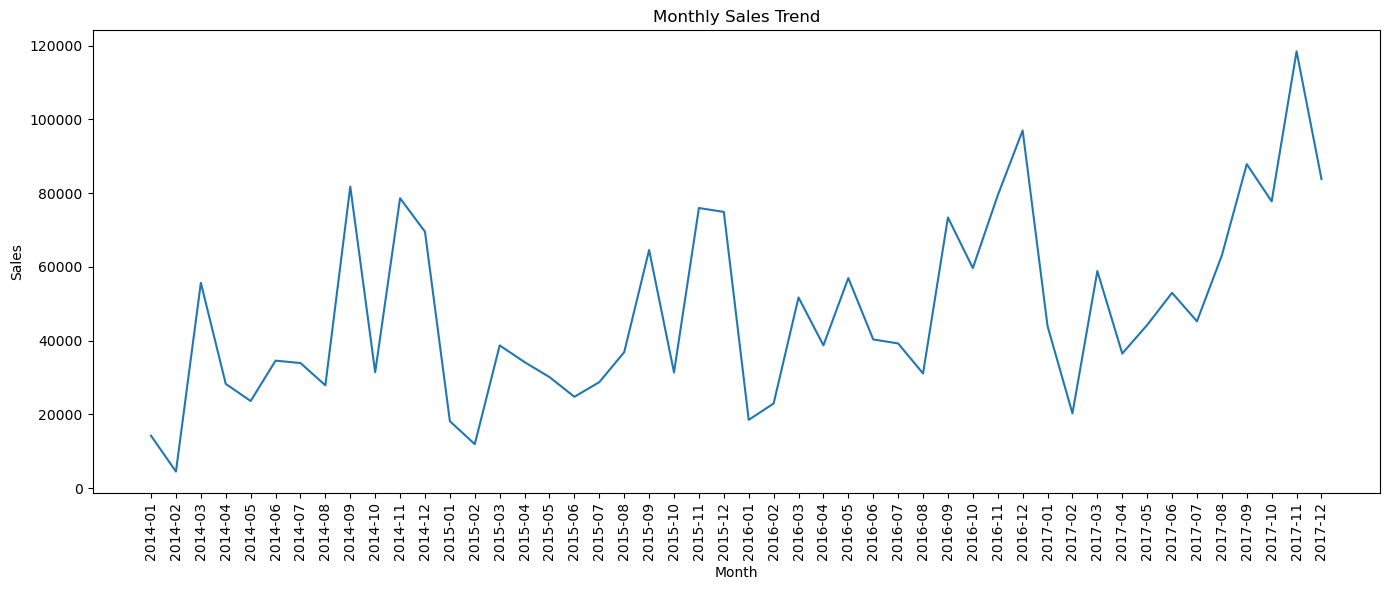

In [12]:
# Monthly Sales Trend Chart
import matplotlib.pyplot as plt

monthly_sales["Year-Month"] = monthly_sales["Year-Month"].astype(str)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Year-Month"],
    monthly_sales["Sales"]
)

plt.xticks(rotation=90)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

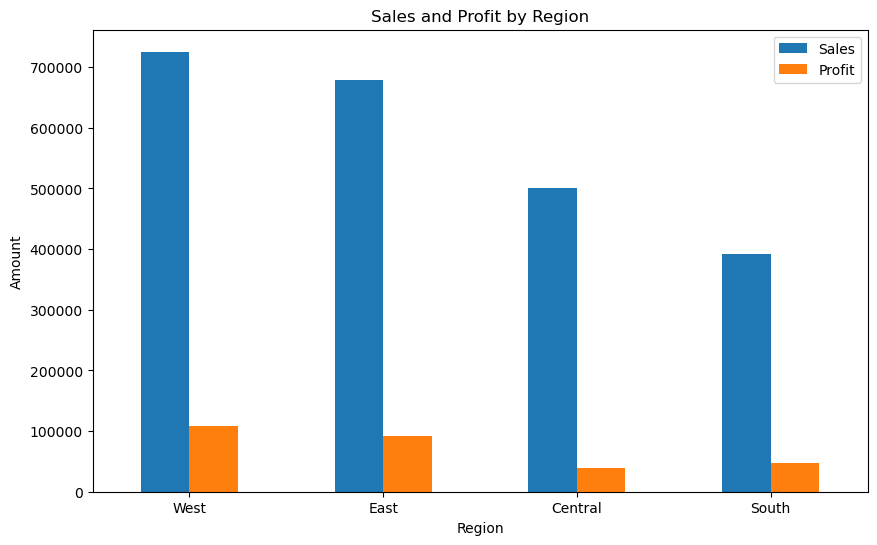

In [13]:
# Sales by Region
region_sales.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sales and Profit by Region")
plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.show()

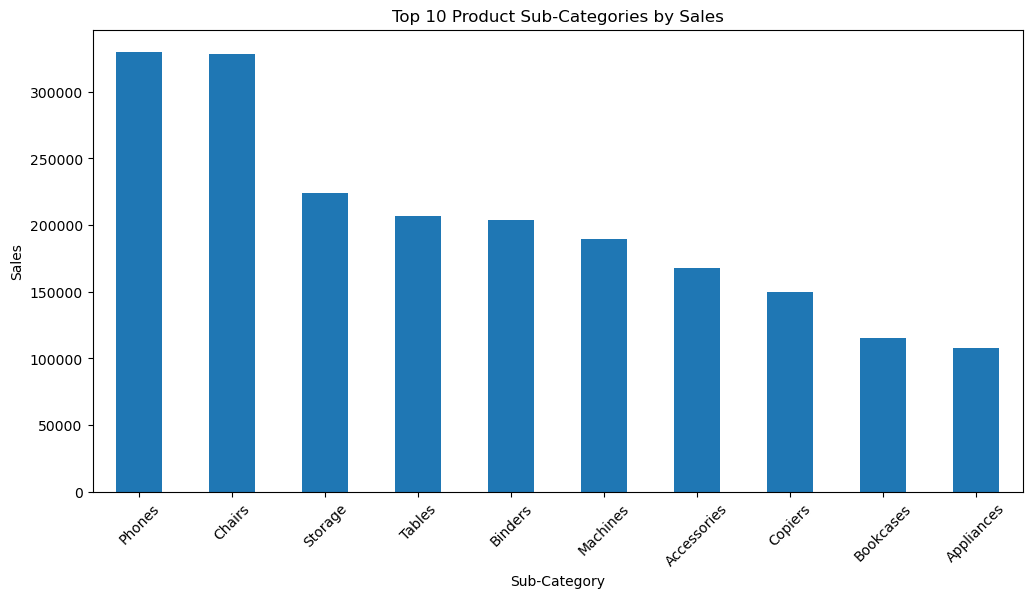

In [14]:
#Top Product Categories
top_products.head(10)["Sales"].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Product Sub-Categories by Sales")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

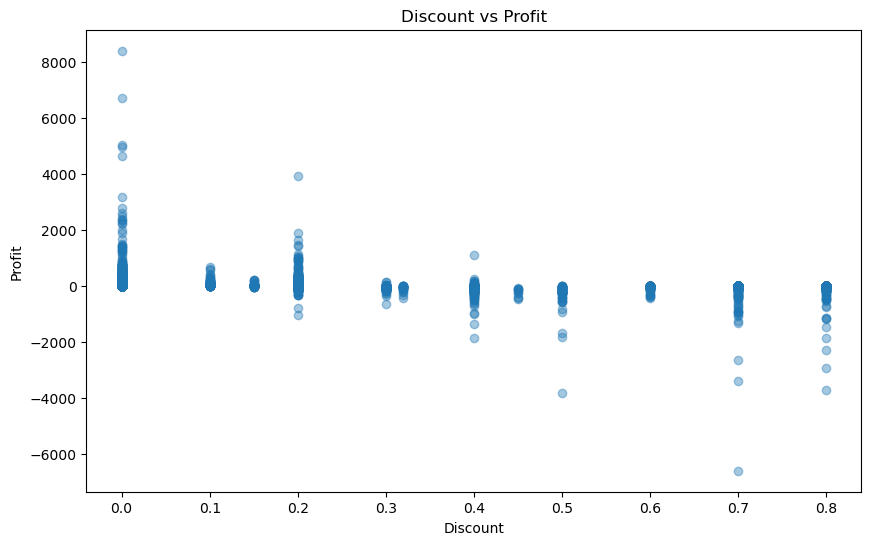

In [16]:
#Profit vs Discount
plt.figure(figsize=(10,6))

plt.scatter(
    sales_df["Discount"],
    sales_df["Profit"],
    alpha=0.4
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()